In [28]:
!curl -LsSf https://astral.sh/uv/install.sh | bash
%cd /content/
%rm -rf CS-5137-Deep-Learning

!git clone https://github.com/toan-ly/CS-5137-Deep-Learning
%cd CS-5137-Deep-Learning
!uv sync

downloading uv 0.9.7 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
/content
Cloning into 'CS-5137-Deep-Learning'...
remote: Enumerating objects: 1400, done.
remote: Counting objects: 100% (208/208), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 1400 (delta 124), reused 157 (delta 76), pack-reused 1192 (from 1)
Receiving objects: 100% (1400/1400), 198.25 MiB | 36.34 MiB/s, done.
Resolving deltas: 100% (500/500), done.
/content/CS-5137-Deep-Learning
Using CPython 3.11.14
Creating virtual environment at: .venv
Resolved 83 packages in 1ms
Installed 77 packages in 409ms
 + asttokens==3.0.0
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.17
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.19.1
 + fonttools==4.59.2
 + fsspec==2025.9.0
 + ipykernel==6.30.1
 + ipython==9.6.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.2
 + jupyter-client==8.

In [29]:
%cd /content/CS-5137-Deep-Learning/homework3/
!uv run -m src.train --config configs/train.yaml \
    --data_root ./data \
    --batch_size 10 --lr 1e-3 --patch_size 128 \
    --base_channels 64 --depth 3 --up_mode bilinear --block_type base --norm_type batch \
    --save_dir checkpoints/norm --save_plots_path results/predictions/norm

/content/CS-5137-Deep-Learning/homework3
Loading dataset: 100% 64/64 [00:01<00:00, 47.04it/s]
Loading dataset: 100% 16/16 [00:00<00:00, 46.12it/s]
Image batch shape: torch.Size([80, 4, 128, 128])
Mask batch shape: torch.Size([80, 1, 128, 128])

Image batch shape: torch.Size([10, 4, 512, 512])
Mask batch shape: torch.Size([10, 1, 512, 512])

Model summary:
UNet(
  (activation): LeakyReLU(negative_slope=0.1, inplace=True)
  (encoder): ModuleList(
    (0): DownBlock(
      (double_conv): DoubleConv(
        (act): LeakyReLU(negative_slope=0.1, inplace=True)
        (double_conv): Sequential(
          (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1, inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [30]:
%cd /content/CS-5137-Deep-Learning/homework3/
!uv run -m src.train --config configs/train.yaml \
    --data_root ./data \
    --batch_size 10 --lr 1e-3 --patch_size 128 \
    --base_channels 64 --depth 3 --up_mode bilinear --block_type base \
    --save_dir checkpoints/no_norm --save_plots_path results/predictions/no_norm

/content/CS-5137-Deep-Learning/homework3
Loading dataset: 100% 64/64 [00:01<00:00, 47.08it/s]
Loading dataset: 100% 16/16 [00:00<00:00, 47.78it/s]
Image batch shape: torch.Size([80, 4, 128, 128])
Mask batch shape: torch.Size([80, 1, 128, 128])

Image batch shape: torch.Size([10, 4, 512, 512])
Mask batch shape: torch.Size([10, 1, 512, 512])

Model summary:
UNet(
  (activation): LeakyReLU(negative_slope=0.1, inplace=True)
  (encoder): ModuleList(
    (0): DownBlock(
      (double_conv): DoubleConv(
        (act): LeakyReLU(negative_slope=0.1, inplace=True)
        (double_conv): Sequential(
          (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): LeakyReLU(negative_slope=0.1, inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): LeakyReLU(negative_slope=0.1, inplace=True)
        )
      )
      (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_loss(loss_df, save_dir):
    legend_loc = 'lower right'
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(loss_df['epoch'], loss_df['train_loss'], label='train_loss')
    axs[0].plot(loss_df['epoch'], loss_df['val_loss'], label='val_loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].legend(loc=legend_loc)

    axs[1].plot(loss_df['epoch'], loss_df['train_dice'], label='train_dice')
    axs[1].plot(loss_df['epoch'], loss_df['val_dice'], label='val_dice')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Dice')
    axs[1].set_title('Training and Validation Dice')
    axs[1].legend(loc=legend_loc)

    axs[2].plot(loss_df['epoch'], loss_df['train_iou'], label='train_iou')
    axs[2].plot(loss_df['epoch'], loss_df['val_iou'], label='val_iou')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('IoU')
    axs[2].set_title('Training and Validation IoU')
    axs[2].legend(loc=legend_loc)

    plt.tight_layout()

    # os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, 'train_curve.png'))
    plt.show()

/content/CS-5137-Deep-Learning/homework3


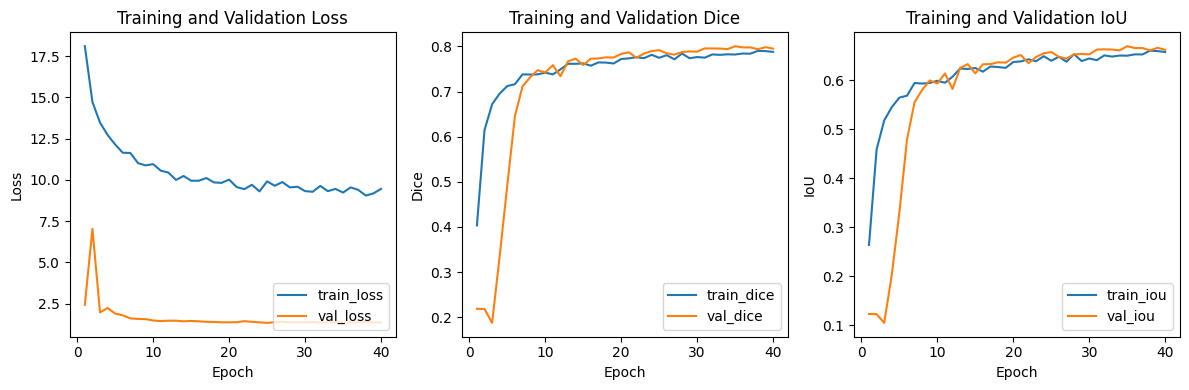

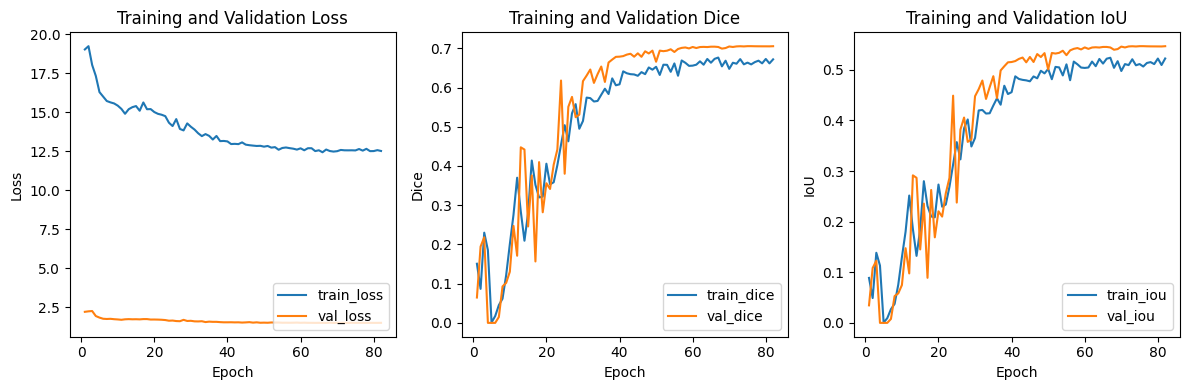

In [32]:
%cd /content/CS-5137-Deep-Learning/homework3/
history_norm = pd.read_csv('checkpoints/norm/training_history.csv')
plot_loss(history_norm, 'results/predictions/norm')
history_no_norm = pd.read_csv('checkpoints/no_norm/training_history.csv')
plot_loss(history_no_norm, 'results/predictions/no_norm')

# Download weights

In [33]:
from google.colab import files
!zip -r checkpoints.zip checkpoints results
files.download('checkpoints.zip')

  adding: checkpoints/ (stored 0%)
  adding: checkpoints/no_norm/ (stored 0%)
  adding: checkpoints/no_norm/best_model.pth (deflated 7%)
  adding: checkpoints/no_norm/training_history.csv (deflated 50%)
  adding: checkpoints/norm/ (stored 0%)
  adding: checkpoints/norm/best_model.pth (deflated 7%)
  adding: checkpoints/norm/training_history.csv (deflated 49%)
  adding: results/ (stored 0%)
  adding: results/predictions/ (stored 0%)
  adding: results/predictions/no_norm/ (stored 0%)
  adding: results/predictions/no_norm/epoch_40.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_80.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_20.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_35.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_65.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_45.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_25.png (deflated 4%)
  adding: results/predictions/no_norm/epoch_70.png (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>